## 3. Exercise 1: Implement the Hungarian Algorithm for Graph Matching


In [199]:
import numpy as np
from PIL import Image
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay 
from scipy.optimize import linear_sum_assignment
import os

#------------------------------------------------------------------------------------------#

def load_and_preprocess_images(img_path1, img_path2, mat_path1, mat_path2):
    """
    Carga y preprocesa pares de imágenes y sus keypoints
    """
    # Definimos tamaño objeto
    obj_resize = (256,256)
    #Definimos las listas donde vamos a guardar los distintos elementos
    imgs = []
    kpts_list = []

    paths = [[img_path1, mat_path1],[img_path2, mat_path2]]

    for img_path, mat_path in paths:
        img = Image.open(img_path)
        kpts = np.array(sio.loadmat(mat_path)['pts_coord'])
        kpts[0] = kpts[0] * obj_resize[0] / img.size[0]
        kpts[1] = kpts[1] * obj_resize[1] / img.size[1]
        img = img.resize(obj_resize, resample=Image.BILINEAR)
        kpts_list.append(kpts)
        imgs.append(img)
    # Devolvemos los valores para poder usar la otra función
    return imgs[0], imgs[1], kpts_list[0], kpts_list[1]

#------------------------------------------------------------------------------------------#

def delaunay_triangulation(kpts):
    """
    Generate adjacency matrix based on Delaunay triangulation
    """
    # Transponemos para tener puntos como filas
    pts = kpts.T
    
    # Calculamos la triangulación de Delaunay
    tri = Delaunay(pts)
    
    # Inicializamos la matriz de adyacencia con ceros
    N = pts.shape[0]
    A = np.zeros((N, N), dtype=int)

    # Recorremos cada triángulo
    for triangle in tri.simplices:
        # triangle tiene 3 vértices: a, b, c
        a = triangle[0]
        b = triangle[1]
        c = triangle[2]

        # Conectamos a con b
        A[a, b] = 1
        A[b, a] = 1  # matriz simétrica

        # Conectamos b con c
        A[b, c] = 1
        A[c, b] = 1

        # Conectamos a comn c
        A[a, c] = 1
        A[c, a] = 1

    return A

#--------------------------------------------------------------------------------------------#

def simple_spatial_matching(kpts1, kpts2):
    """
    Realiza matching entre puntos usando distancia euclidiana y algoritmo húngaro optimizado
    
    Args:
        kpts1: Array de keypoints del primer grafo (2xN)
        kpts2: Array de keypoints del segundo grafo (2xN)
    
    Returns:
        matching: Matriz binaria donde matching[i,j]=1 indica correspondencia entre puntos
    Hints:
        - Primero deberás crear una matriz de costes basada en distancias euclidianas,
        cuyo tamaño será (n1, n2) donde n1 y n2 son el número de keypoints en cada grafo.
        - Seguidamente, deberás rellenar dicha matriz con las distancias euclidianas entre
        los keypoints de ambos grafos.
        - A continuación, deberás aplicar el algoritmo húngaro usando la función linear_sum_assignment, que recibe la matriz de costes y devuelve los índices de los puntos emparejados.
        - Finalmente, deberás crear una matriz de matching a partir de los índices obtenidos.

    """
    
    n1, n2 = kpts1.shape[1], kpts2.shape[1]
    cost_matrix= np.zeros((n1,n2))
    for i in range(n1):
        for j in range(n2):
            cost_matrix[i,j] = np.sqrt(np.sum((kpts1[:,i] - kpts2[:,j])**2))
    
    row_index,col_index = linear_sum_assignment(cost_matrix)
    # Pasamos de un array de 2XE a un array de NxN
    matching = np.zeros((n1,n2))
    matching[row_index,col_index] = 1
    return matching

#----------------------------------------------------------------------------------------------#

def visualize_matching_full(img1, img2, kpts1, kpts2, adj_matrix1, adj_matrix2, matching):
    """
    Visualiza el matching completo entre dos grafos
    """
    
    # Graficar una imagen al lado de otra
    plt.figure(figsize=(15,8))
    # SI ya estan redimensionadas no haria falta (el max), simplemente se haria ancho = img1.shape
    ancho = max (img1.size[0],img2.size[0])
    alto = max (img1.size[1],img2.size[1])
    composicion = Image.new('RGB', (ancho*2, alto))
    composicion.paste(img1, (0,0))
    composicion.paste(img2, (ancho,0))
    plt.imshow(composicion)
    
    
    # Graficar las coordenadas (keypoints)
    plt.scatter(kpts1[0], kpts1[1], c='w', edgecolors='k', s=100)
    plt.scatter(kpts2[0] + ancho, kpts2[1], c='w', edgecolors='k', s=100)


    # Aristas imagen 1
    for i in range(adj_matrix1.shape[0]):
        for j in range(adj_matrix1.shape[1]):
            if adj_matrix1[i,j] == 1:
                plt.plot([kpts1[0,i], kpts1[0,j]],
                         [kpts1[1,i], kpts1[1,j]],
                         'y-', linewidth=0.5)

    # Aristas  imagen 2
    for i in range(adj_matrix2.shape[0]):
        for j in range(adj_matrix2.shape[1]):
            if adj_matrix2[i,j] == 1:
                plt.plot([kpts2[0,i] + ancho, kpts2[0,j] + ancho],
                         [kpts2[1,i], kpts2[1,j]],
                         'y-', linewidth=0.5)

    # Graficamoslas arsitas del matching
    for i in range(matching.shape[0]):
        for j in range(matching.shape[1]):
            if matching[i,j] > 0:
                color = 'g' if i==j else 'r'
                plt.plot([kpts1[0,i], kpts2[0,j] + ancho],
                         [kpts1[1,i], kpts2[1,j]],
                         color = color, linewidth=2)
    
#----------------------------------------------------------------------------------------#

## EXERCISE 2: Visualize the Optimal Assigment

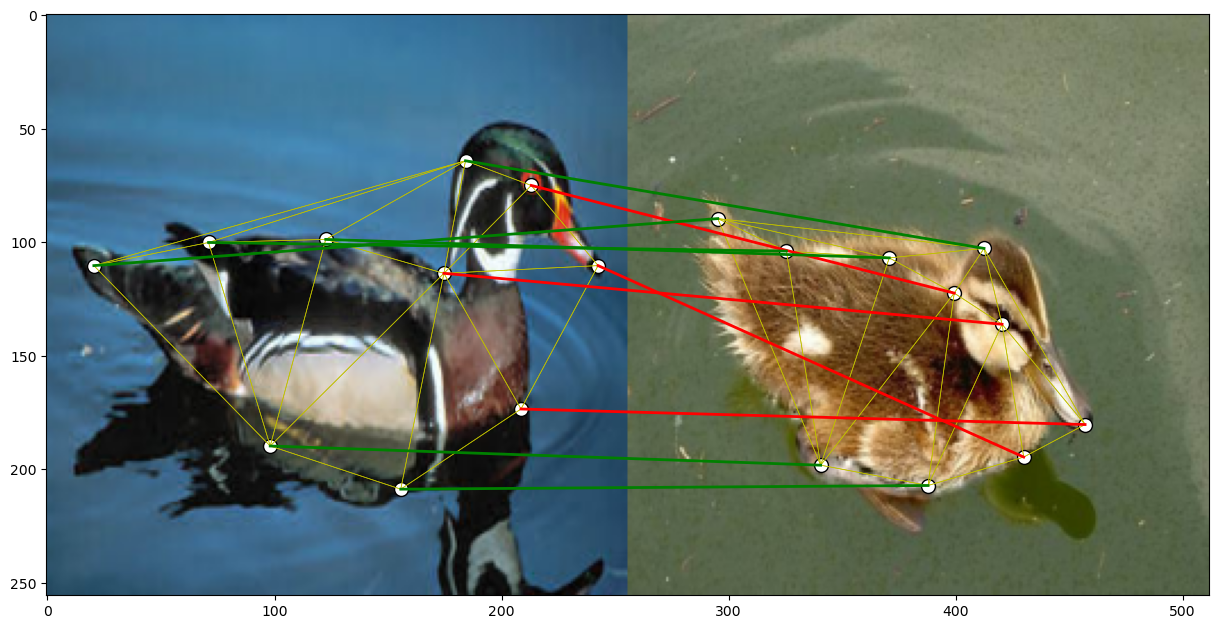

In [200]:
# Ejercicio 2

# Cargamos las rutas el par de imágenes
img_path1 = './data/WillowObject/WILLOW-ObjectClass/Duck/060_0081.png'
mat_path1 = './data/WillowObject/WILLOW-ObjectClass/Duck/060_0081.mat'

img_path2 = './data/WillowObject/WILLOW-ObjectClass/Duck/060_0066.png'
mat_path2 = './data/WillowObject/WILLOW-ObjectClass/Duck/060_0066.mat'

img1, img2, kpt1, kpt2 = load_and_preprocess_images(img_path1, img_path2, mat_path1, mat_path2)

# Aplicamos Delaunay
matriz = delaunay_triangulation(kpt1)
matriz2 = delaunay_triangulation(kpt2)
# Hacemos el matching
matching = simple_spatial_matching(kpt1, kpt2)

# Visualizamos el matching completo
visualize_matching_full(img1, img2, kpt1, kpt2, matriz, matriz2, matching)

## EXERCISE 3: Evaluate the Matching Results

Vamos a crear una función que evalue la precisión del matching:

In [201]:
def accuracy(matching):
    """
    Calculamos la precisión del matching

    Parámetros
    ----------
    - matching: Matching (necesario para la evaluación de la precisión)

    Fórmula
    -------
    - accuracy = nº puntos emparejados correctamente / nº total de puntos clave

    Funcionamiento
    --------------
    - Para saber si dos puntos claves se han emparejado correctamente, se cumple 
      la condición: matching[i,j] == 1 and i == j (cada vez que esto suceda, incrementamos
      en una unidad el contador de matches correctos)
    
    """

    matches_correctos = 0
    total_puntos = matching.shape[0]

    for i in range(matching.shape[0]):
        for j in range(matching.shape[1]):
            if matching[i,j] == 1 and i == j:
                matches_correctos += 1

    accuracy = matches_correctos / total_puntos

    return accuracy

Ahora que tenemos una función que compara la precisión del matching entre dos imágenes, vamos a crear otra que recorra todas las imágenes de una categoría y las vaya comparando para así obtener el accuracy de cada categoría

In [202]:
def accuracy_categoria(category):
    """
    Función que recorre las imágenes de una categoría, va realizando matching entre 
    ellas y va calculando preciones. Una vez tiene una lista de precisiones, se 
    calcula la media para saber el accuracy de la categoría
    """

    path = './data/WillowObject/WILLOW-ObjectClass/' + category

    # Listas para guardar las imágenes y archivos .mat
    pngs = []
    mats = []

    for img in os.listdir(path):
        if img.endswith('.png'):
            pngs.append(img)
        elif img.endswith('.mat'):
            mats.append(img)
    
    pngs = sorted(pngs)
    mats = sorted(mats)

    accuracies = []

    # Vamos a recorrer la categoría
    for i in range(len(pngs)-1):
        img_path1 = path + '/' + pngs[i]
        mat_path1 = path + '/' + mats[i]

        img_path2 = path + '/' + pngs[i + 1]
        mat_path2 = path + '/' + mats[i + 1]

        # Una vez que tenemos las rutas de las imagenes, aplicamos el procedimiento anterior

        img1, img2, kpt1, kpt2 = load_and_preprocess_images(img_path1, img_path2, mat_path1, mat_path2)

        # Hacemos el matching
        matching = simple_spatial_matching(kpt1, kpt2)

        # Calculamos el accuracy
        acc = accuracy(matching)
        accuracies.append(acc)

    # Calculamos la media
    x = len(accuracies)
    total = sum(accuracies)
    media = total/x

    # Calculamos la desviación típica
    desviacion = np.std(accuracies)

    return media, desviacion

## Evaluamos los resultados por categoría

Se nos pide guardar un csv con los resultados de cada categoria, para ello vamos a crear un DataFrame usando la librería `Pandas`

In [203]:
import pandas as pd

Vamos a crear el DataFrame para ir guardando las categorías. Para ello vamos a emplear un diccionario de momento vacío:

In [204]:
# Usamos un diccionario

data = {
    'Categoría' : [],
    'Precisión Media' : [],
    'Desviación Estandar': []
}

df = pd.DataFrame(data)
print(df)

Empty DataFrame
Columns: [Categoría, Precisión Media, Desviación Estandar]
Index: []


## Car

Ejemplo de como se calcula el accuracy entre dos imágenes

ACCURACY -> 0.5


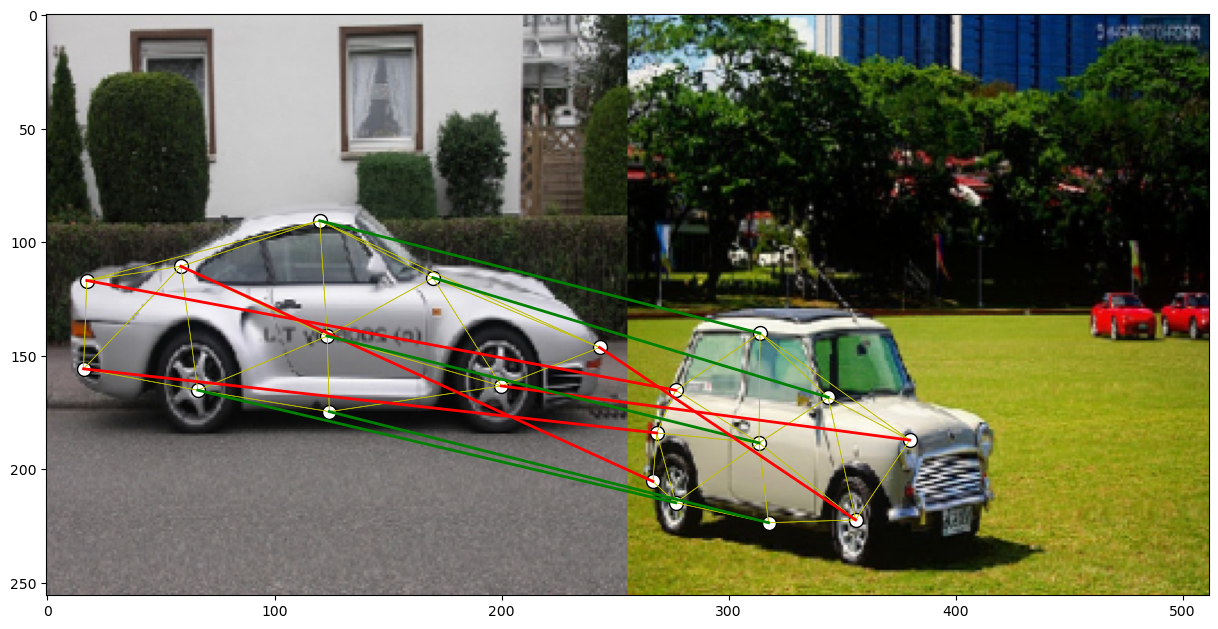

In [205]:
# Cargamos las rutas el par de imágenes (categoría Car)
img_path1 = './data/WillowObject/WILLOW-ObjectClass/Car/Cars_000a.png'
mat_path1 = './data/WillowObject/WILLOW-ObjectClass/Car/Cars_000a.mat'

img_path2 = './data/WillowObject/WILLOW-ObjectClass/Car/Cars_008b.png'
mat_path2 = './data/WillowObject/WILLOW-ObjectClass/Car/Cars_008b.mat'

img1, img2, kpt1, kpt2 = load_and_preprocess_images(img_path1, img_path2, mat_path1, mat_path2)

# Aplicamos Delaunay
matriz = delaunay_triangulation(kpt1)
matriz2 = delaunay_triangulation(kpt2)
# Hacemos el matching
matching = simple_spatial_matching(kpt1, kpt2)

# Visualizamos el matching completo
visualize_matching_full(img1, img2, kpt1, kpt2, matriz, matriz2, matching)

# Calculamos el accuracy
acc = accuracy(matching)

print(f'ACCURACY -> {acc}')


### Calculamos la media y desviación para categoría CAR:

In [206]:
category = 'Car'
datos = accuracy_categoria(category)
print(f'INFORMACIÓN CATEGORÍA CAR:\nPrecisión media -> {datos[0]:.2f} \
      \nDesviación típica -> {datos[1]:.2f}')

# Guardamos la información en nuestro DataFrame
df.loc[0] = [category, round(datos[0],3), round(datos[1],3)]

# Mostramos el DataFrame
print('\n-------------------------DATOS---------------------------')
print(df)

INFORMACIÓN CATEGORÍA CAR:
Precisión media -> 0.73       
Desviación típica -> 0.34

-------------------------DATOS---------------------------
  Categoría  Precisión Media  Desviación Estandar
0       Car            0.733                0.337


### Duck

Ejemplo de como se calcula el accuracy entre dos imágenes

ACCURACY -> 0.6


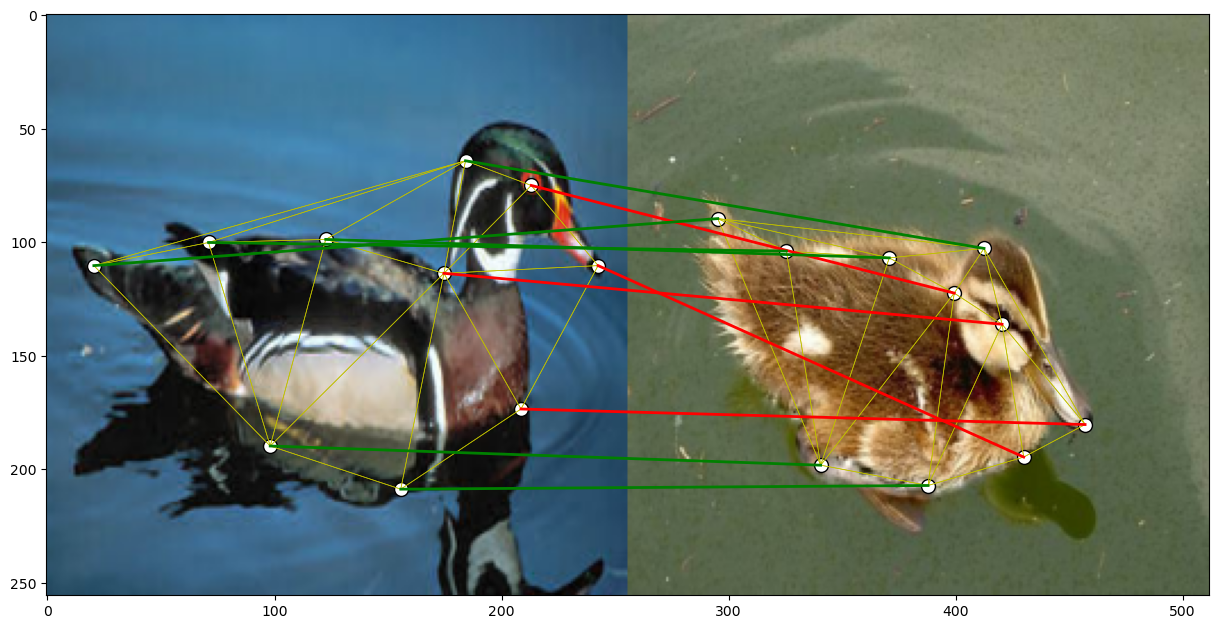

In [207]:
# Cargamos las rutas el par de imágenes (categoría Duck)
img_path1 = './data/WillowObject/WILLOW-ObjectClass/Duck/060_0081.png'
mat_path1 = './data/WillowObject/WILLOW-ObjectClass/Duck/060_0081.mat'

img_path2 = './data/WillowObject/WILLOW-ObjectClass/Duck/060_0066.png'
mat_path2 = './data/WillowObject/WILLOW-ObjectClass/Duck/060_0066.mat'

img1, img2, kpt1, kpt2 = load_and_preprocess_images(img_path1, img_path2, mat_path1, mat_path2)

# Aplicamos Delaunay
matriz = delaunay_triangulation(kpt1)
matriz2 = delaunay_triangulation(kpt2)
# Hacemos el matching
matching = simple_spatial_matching(kpt1, kpt2)

# Visualizamos el matching completo
visualize_matching_full(img1, img2, kpt1, kpt2, matriz, matriz2, matching)

# Calculamos el accuracy
acc = accuracy(matching)

print(f'ACCURACY -> {acc}')


### Calculamos la media y desviación para categoría DUCK:

In [208]:
category = 'Duck'
datos = accuracy_categoria(category)
print(f'INFORMACIÓN CATEGORÍA DUCK:\nPrecisión media -> {datos[0]:.2f} \
      \nDesviación típica -> {datos[1]:.2f}')

# Guardamos la información en nuestro DataFrame
df.loc[1] = [category, round(datos[0],3), round(datos[1],3)]

# Mostramos el DataFrame
print('\n-------------------------DATOS---------------------------')
print(df)

INFORMACIÓN CATEGORÍA DUCK:
Precisión media -> 0.77       
Desviación típica -> 0.30

-------------------------DATOS---------------------------
  Categoría  Precisión Media  Desviación Estandar
0       Car            0.733                0.337
1      Duck            0.767                0.297


### Face

Ejemplo de como se calcula el accuracy entre dos imágenes

ACCURACY -> 1.0


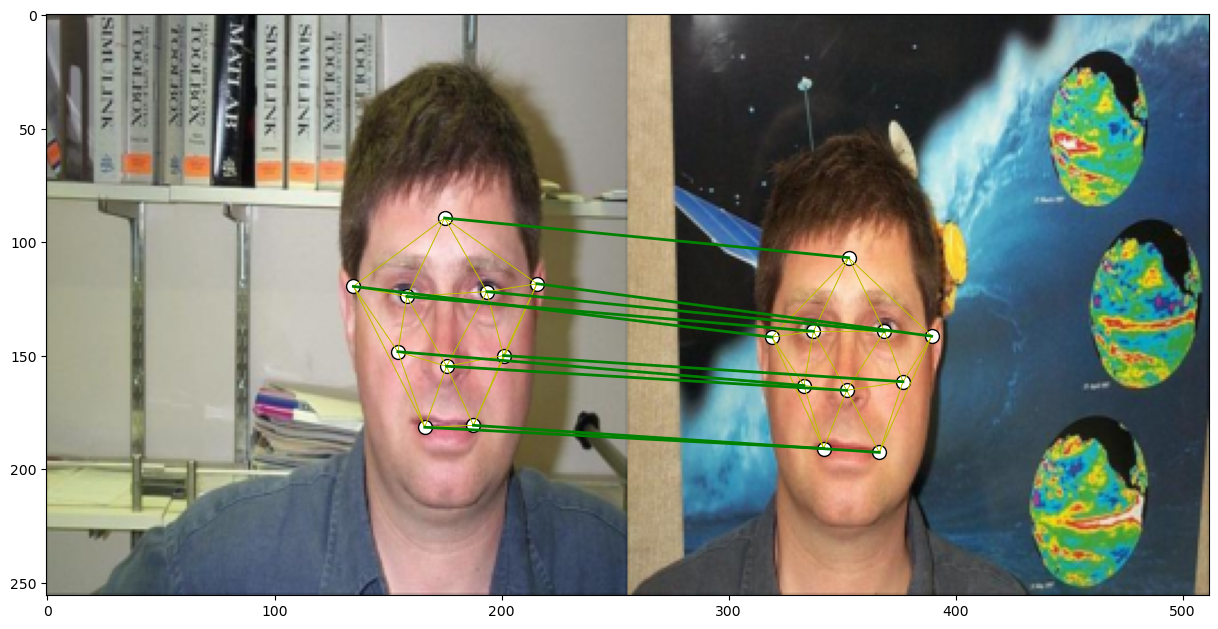

In [209]:
# Cargamos las rutas el par de imágenes (categoría Face)
img_path1 = './data/WillowObject/WILLOW-ObjectClass/Face/image_0001.png'
mat_path1 = './data/WillowObject/WILLOW-ObjectClass/Face/image_0001.mat'

img_path2 = './data/WillowObject/WILLOW-ObjectClass/Face/image_0004.png'
mat_path2 = './data/WillowObject/WILLOW-ObjectClass/Face/image_0004.mat'

img1, img2, kpt1, kpt2 = load_and_preprocess_images(img_path1, img_path2, mat_path1, mat_path2)

# Aplicamos Delaunay
matriz = delaunay_triangulation(kpt1)
matriz2 = delaunay_triangulation(kpt2)
# Hacemos el matching
matching = simple_spatial_matching(kpt1, kpt2)

# Visualizamos el matching completo
visualize_matching_full(img1, img2, kpt1, kpt2, matriz, matriz2, matching)

# Calculamos el accuracy
acc = accuracy(matching)

print(f'ACCURACY -> {acc}')


### Calculamos la media y desviación para categoría FACE:

In [210]:
category = 'Face'
datos = accuracy_categoria(category)
print(f'INFORMACIÓN CATEGORÍA FACE:\nPrecisión media -> {datos[0]:.2f} \
      \nDesviación típica -> {datos[1]:.2f}')

# Guardamos la información en nuestro DataFrame
df.loc[2] = [category, round(datos[0],3), round(datos[1],3)]

# Mostramos el DataFrame
print('\n-------------------------DATOS---------------------------')
print(df)

INFORMACIÓN CATEGORÍA FACE:
Precisión media -> 0.92       
Desviación típica -> 0.14

-------------------------DATOS---------------------------
  Categoría  Precisión Media  Desviación Estandar
0       Car            0.733                0.337
1      Duck            0.767                0.297
2      Face            0.923                0.142


### Motorbike

Ejemplo de como se calcula el accuracy entre dos imágenes

ACCURACY -> 0.3


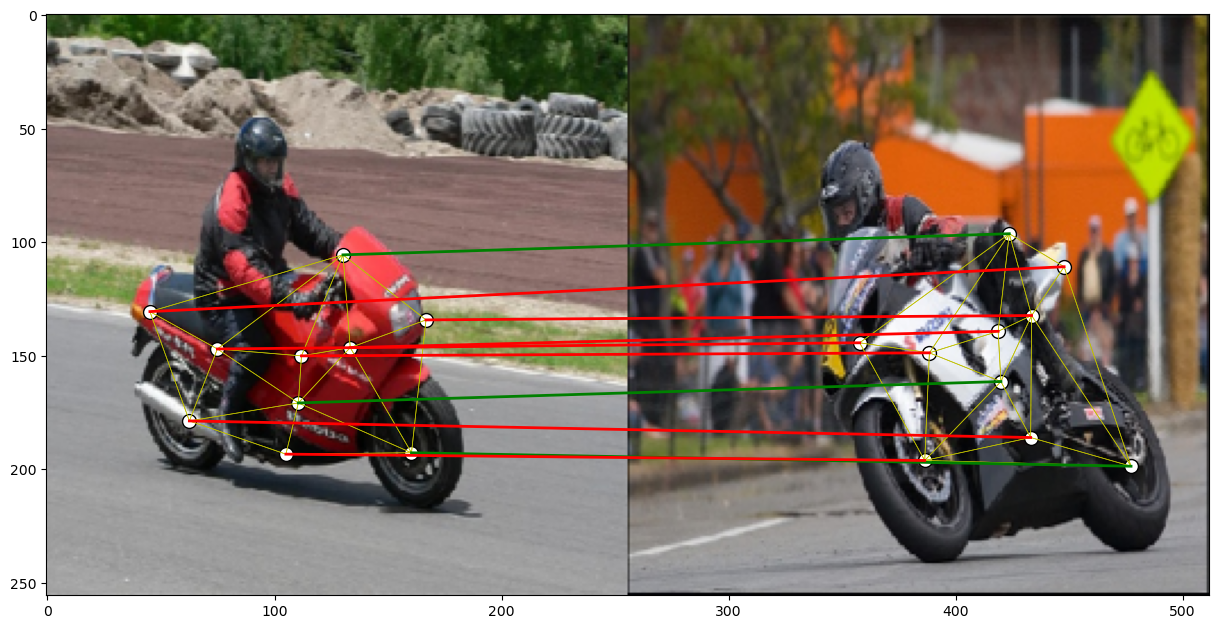

In [211]:
# Cargamos las rutas el par de imágenes (categoría Motorbike)
img_path1 = './data/WillowObject/WILLOW-ObjectClass/Motorbike/Motorbikes_001a.png'
mat_path1 = './data/WillowObject/WILLOW-ObjectClass/Motorbike/Motorbikes_001a.mat'

img_path2 = './data/WillowObject/WILLOW-ObjectClass/Motorbike/Motorbikes_005b.png'
mat_path2 = './data/WillowObject/WILLOW-ObjectClass/Motorbike/Motorbikes_005b.mat'

img1, img2, kpt1, kpt2 = load_and_preprocess_images(img_path1, img_path2, mat_path1, mat_path2)

# Aplicamos Delaunay
matriz = delaunay_triangulation(kpt1)
matriz2 = delaunay_triangulation(kpt2)
# Hacemos el matching
matching = simple_spatial_matching(kpt1, kpt2)

# Visualizamos el matching completo
visualize_matching_full(img1, img2, kpt1, kpt2, matriz, matriz2, matching)

# Calculamos el accuracy
acc = accuracy(matching)

print(f'ACCURACY -> {acc}')


### Calculamos la media y desviación para categoría MOTORBIKE:

In [212]:
category = 'Motorbike'
datos = accuracy_categoria(category)
print(f'INFORMACIÓN CATEGORÍA MOTORBIKE:\nPrecisión media -> {datos[0]:.2f} \
      \nDesviación típica -> {datos[1]:.2f}')

# Guardamos la información en nuestro DataFrame
df.loc[3] = [category, round(datos[0],3), round(datos[1],3)]

# Mostramos el DataFrame
print('\n-------------------------DATOS---------------------------')
print(df)

INFORMACIÓN CATEGORÍA MOTORBIKE:
Precisión media -> 0.93       
Desviación típica -> 0.14

-------------------------DATOS---------------------------
   Categoría  Precisión Media  Desviación Estandar
0        Car            0.733                0.337
1       Duck            0.767                0.297
2       Face            0.923                0.142
3  Motorbike            0.928                0.145


### Winebottle

Ejemplo de como se calcula el accuracy entre dos imágenes

ACCURACY -> 1.0


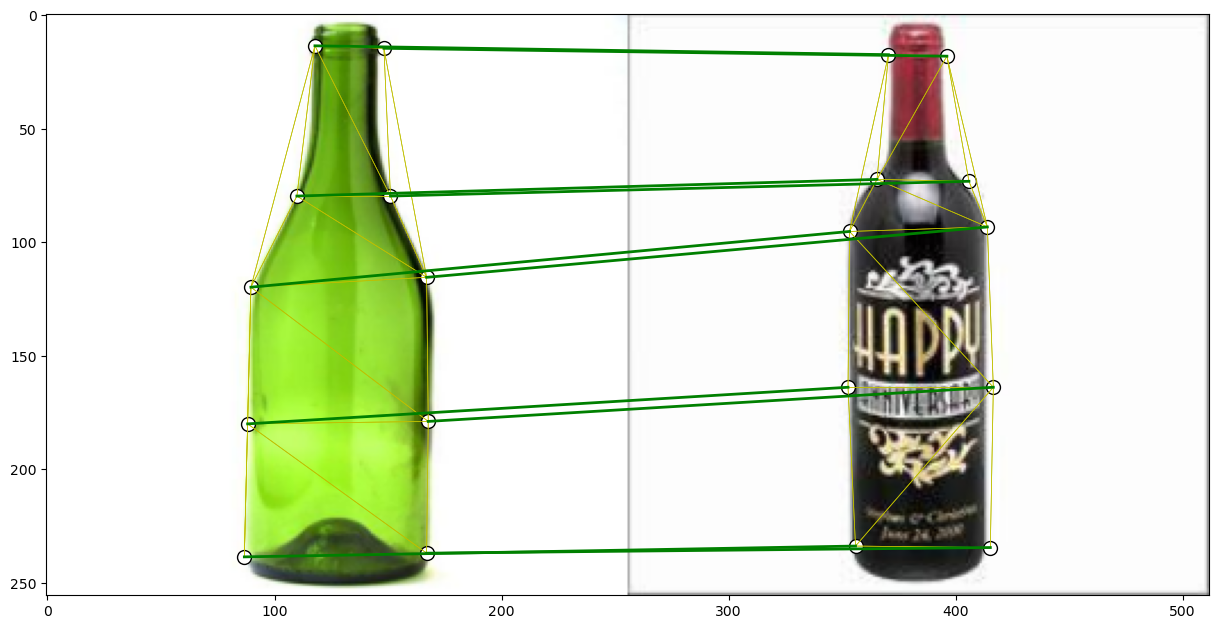

In [213]:
# Cargamos las rutas el par de imágenes (categoría Winebottle)
img_path1 = './data/WillowObject/WILLOW-ObjectClass/Winebottle/246_0001.png'
mat_path1 = './data/WillowObject/WILLOW-ObjectClass/Winebottle/246_0001.mat'

img_path2 = './data/WillowObject/WILLOW-ObjectClass/Winebottle/246_0002.png'
mat_path2 = './data/WillowObject/WILLOW-ObjectClass/Winebottle/246_0002.mat'

img1, img2, kpt1, kpt2 = load_and_preprocess_images(img_path1, img_path2, mat_path1, mat_path2)

# Aplicamos Delaunay
matriz = delaunay_triangulation(kpt1)
matriz2 = delaunay_triangulation(kpt2)
# Hacemos el matching
matching = simple_spatial_matching(kpt1, kpt2)

# Visualizamos el matching completo
visualize_matching_full(img1, img2, kpt1, kpt2, matriz, matriz2, matching)

# Calculamos el accuracy
acc = accuracy(matching)

print(f'ACCURACY -> {acc}')

### Calculamos la media y desviación para categoría MOTORBIKE:

In [214]:
category = 'Winebottle'
datos = accuracy_categoria(category)
print(f'INFORMACIÓN CATEGORÍA WINEBOTTLE:\nPrecisión media -> {datos[0]:.2f} \
      \nDesviación típica -> {datos[1]:.2f}')

# Guardamos la información en nuestro DataFrame
df.loc[4] = [category, round(datos[0],3), round(datos[1],3)]

# Mostramos el DataFrame
print('\n-------------------------DATOS---------------------------')
print(df)

INFORMACIÓN CATEGORÍA WINEBOTTLE:
Precisión media -> 0.88       
Desviación típica -> 0.21

-------------------------DATOS---------------------------
    Categoría  Precisión Media  Desviación Estandar
0         Car            0.733                0.337
1        Duck            0.767                0.297
2        Face            0.923                0.142
3   Motorbike            0.928                0.145
4  Winebottle            0.882                0.214


Obteniendo el siguiente DataFrame:

In [215]:
print(df)

    Categoría  Precisión Media  Desviación Estandar
0         Car            0.733                0.337
1        Duck            0.767                0.297
2        Face            0.923                0.142
3   Motorbike            0.928                0.145
4  Winebottle            0.882                0.214


## Resultados en un archivo .csv

In [216]:
df.to_csv('data.csv', index=False)